##  Setup and Data Loading

The HealthConnect appointment dataset and its data dictionary are loaded using
Pandas. The data dictionary will be used to understand the meaning and expected
constraints of the fields.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("HealthConnect_Appointment_Data.csv")
dd = pd.read_csv("HealthConnect_Data_Dictionary - Data Dictionary.csv")



### Result

The two CSV files were successfully loaded into Pandas:

- `df` contains the appointment records.
- `dd` contains the data dictionary describing the dataset fields.

##  Dataset Dimensions

The first check examines the number of rows and columns in the appointment dataset.

In [3]:
df.shape

(5000, 18)

### Observation

The dataset contains **5,000 appointment records and 18 columns**. Each row represents
an appointment, while the columns contain patient, booking, appointment, reminder,
logistical, and outcome information.

##  Data Types

The data types of each column are reviewed to identify whether variables have been
loaded in an appropriate format for analysis.

In [4]:
df.dtypes

appointment_id            object
patient_id                object
gender                    object
age                        int64
age_group                 object
appointment_type          object
booking_date              object
appointment_date          object
appointment_day           object
appointment_time          object
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent             object
reminder_channel          object
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome       object
dtype: object

### Observation

The dataset contains:

- 4 integer columns
- 2 floating-point columns
- 12 object/string columns

The `booking_date` and `appointment_date` fields are initially stored as `object`
data types. These will be converted to datetime format before date validation.

##  Preview of the Dataset

The first five rows are displayed to inspect the structure and values of the records.

In [5]:
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


### Observation

The preview confirms that the dataset contains information about patient
characteristics, appointment details, booking behaviour, reminders, distance,
waiting time, and appointment outcomes.

##  Dataset Information

`df.info()` is used to review the number of non-null values, data types, and
overall memory structure of the dataset.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

### Observation

Most columns contain 5,000 non-null records. Missing values are present in three
fields:

- `reminder_channel`
- `distance_to_clinic_km`
- `waiting_time_minutes`

The remaining fields contain complete records at this stage.

##  Missing Value Assessment

The number of missing values in each column is calculated to identify fields
requiring further investigation.

In [7]:
df.isna().sum()

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64

### Observation

Missing values were identified in three columns:

- `reminder_channel`: 1,366 missing values
- `distance_to_clinic_km`: 90 missing values
- `waiting_time_minutes`: 60 missing values

The missing values in `reminder_channel` require further investigation because
the field is related to whether a reminder was sent.

##  Duplicate Appointment ID Check

Because `appointment_id` identifies each appointment, duplicate IDs could indicate
duplicate appointment records. A duplicate check is therefore performed.

In [8]:
df['appointment_id'].duplicated().sum()

0

### Observation

The result is **0**, meaning there are no duplicate `appointment_id` values in the
5,000 records. The dataset is therefore clean at the appointment record-identity level.

##  Reminder Status

The reminder status is examined to understand how frequently appointments received
a reminder.

In [9]:
df['reminder_sent'].value_counts()

reminder_sent
Yes    3634
No     1366
Name: count, dtype: int64

### Observation

A reminder was sent for **3,634 appointments**, while **1,366 appointments**
did not receive a reminder.

The 1,366 appointments without reminders correspond exactly to the number of
missing `reminder_channel` values, which requires further validation.

##  Reminder Channel Missingness Validation

The relationship between `reminder_sent` and missing `reminder_channel` values
is checked to determine whether the missing values are structural.

In [10]:
df[df['reminder_sent'] == 'No']['reminder_channel'].isna().sum()

1366

### Observation

All **1,366 appointments where no reminder was sent have a missing
`reminder_channel`**.

This indicates that the missing values are structurally related to
`reminder_sent = "No"` rather than appearing to be random missing data.

Therefore, `reminder_channel` should not be imputed with a communication channel.

##  Reminder Channel Distribution

For appointments where a reminder was sent, the distribution of reminder channels
is examined.

In [11]:
df[df['reminder_sent'] == 'Yes']['reminder_channel'].value_counts()

reminder_channel
SMS         2000
WhatsApp    1101
Email        533
Name: count, dtype: int64

### Observation

Among the 3,634 appointments that received reminders:

- SMS: 2,000
- WhatsApp: 1,101
- Email: 533

SMS was the most frequently used reminder channel, followed by WhatsApp and Email.

This describes usage frequency only; it does not establish that one channel
produces better attendance. Channel effectiveness will be investigated during
the later analysis phase.

##  Logical Consistency Check: Previous No-Shows

A patient's number of previous no-shows should not exceed the number of their
previous appointments. This relationship is checked across the dataset.

In [12]:
(df['previous_no_shows'] > df['previous_appointments']).sum()

0

### Observation

The result is **0**, meaning there are no records where `previous_no_shows`
exceeds `previous_appointments`.

This confirms that these two historical count fields satisfy the checked
logical constraint.

In [13]:
(df['booking_lead_days'] < 0).sum()

0

**Result:** Zero records with a negative `booking_lead_days` value, confirming every appointment was booked on or before its scheduled date.

##  Appointment Outcome Distribution

The distribution of appointment outcomes is examined to understand the overall
attendance pattern in the dataset.

In [14]:
df['appointment_outcome'].value_counts()

appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

### Observation

The dataset contains three appointment outcomes:

- No-Show: 2,423
- Attended: 2,314
- Cancelled: 263

No-Show is the largest outcome category and therefore represents an important
area for further investigation.

In [15]:
df['appointment_outcome'].value_counts(normalize=True).round(3) * 100

appointment_outcome
No-Show      48.5
Attended     46.3
Cancelled     5.3
Name: proportion, dtype: float64

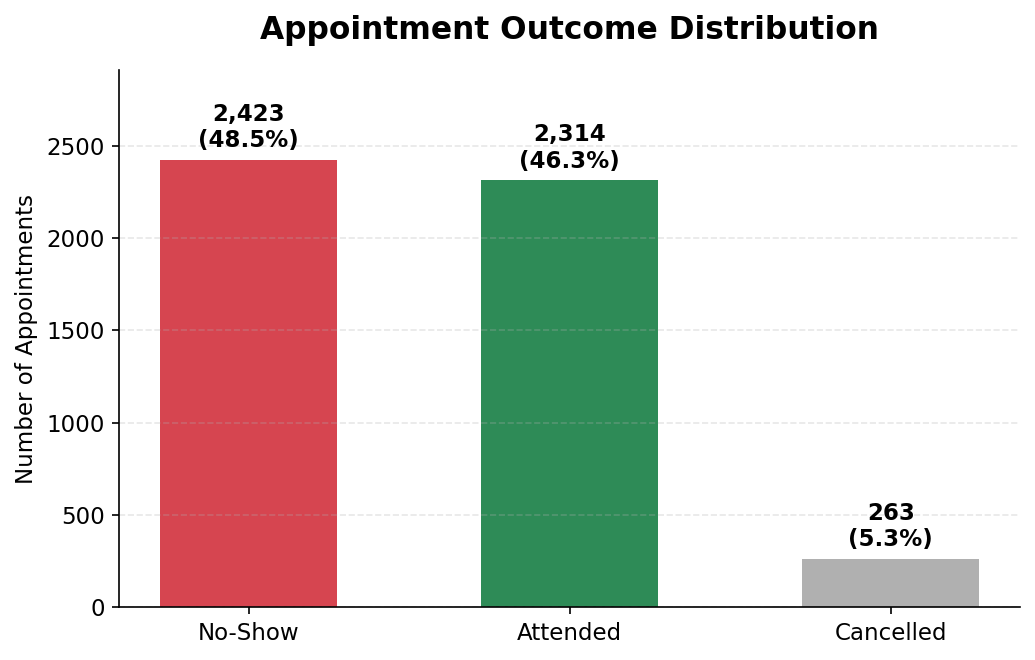

In [16]:
import matplotlib.pyplot as plt
counts = df['appointment_outcome'].value_counts()
pct = df['appointment_outcome'].value_counts(normalize=True) * 100

order = ['No-Show', 'Attended', 'Cancelled']
counts = counts.reindex(order)
pct = pct.reindex(order)

colors = ['#D64550', '#2E8B57', '#B0B0B0']

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
bars = ax.bar(order, counts.values, color=colors, width=0.55)

for bar, count, p in zip(bars, counts.values, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f"{count:,}\n({p:.1f}%)", ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("Appointment Outcome Distribution", fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel("Number of Appointments", fontsize=11)
ax.set_ylim(0, max(counts.values) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Observation
**Observation:** No-Show is the largest outcome category at 48.5%, closely followed by Attended at 46.3%. Cancelled appointments make up a much smaller share at 5.3%. This confirms No-Show as the primary area of concern for the rest of this analysis.

## Appointment Type Distribution

The appointment types are reviewed to understand the composition of the dataset.

In [17]:
df['appointment_type'].value_counts()

appointment_type
General Consultation       2086
Follow-up                  1421
Specialist Consultation     900
Diagnostic Test             593
Name: count, dtype: int64

### Observation

The dataset contains four appointment types:

- General Consultation: 2,086
- Follow-up: 1,421
- Specialist Consultation: 900
- Diagnostic Test: 593

General Consultation is the most common appointment type.

Further analysis will determine whether appointment type is associated with
different no-show rates.

##  Gender Distribution

The gender distribution is reviewed as part of the initial demographic assessment.

In [18]:
df['gender'].value_counts()

gender
Female               2488
Male                 2404
Prefer not to say     108
Name: count, dtype: int64

### Observation

The dataset contains:

- Female: 2,488
- Male: 2,404
- Prefer not to say: 108

The female and male groups are relatively similar in size, while a smaller number
of records use "Prefer not to say."

##  Age Distribution

Descriptive statistics are used to understand the age range and central tendency
of patients in the dataset.

In [19]:
df['age'].describe()

count    5000.000000
mean       48.794800
std        18.138547
min        18.000000
25%        33.000000
50%        49.000000
75%        64.000000
max        80.000000
Name: age, dtype: float64

### Observation

Patient ages range from **18 to 80 years**.

The mean age is approximately **48.8 years**, while the median age is **49 years**.
The first and third quartiles are 33 and 64 years respectively.

This provides the baseline demographic context for later analysis of whether age
is associated with appointment no-shows.

##  Numerical Variable Assessment

The main numerical variables are reviewed for their ranges, central tendencies,
and missing values.

In [20]:
df[['booking_lead_days', 'previous_appointments', 'previous_no_shows',
    'distance_to_clinic_km', 'waiting_time_minutes']].describe()

,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
count,5000.00000,5000.000000,5000.000000,4910.000000,4940.000000
mean,29.63860,3.013800,0.544200,10.109572,24.189676
std,17.39936,1.741211,0.746832,6.590030,10.863184
min,0.00000,0.000000,0.000000,0.500000,2.000000
25%,15.00000,2.000000,0.000000,5.300000,17.000000
50%,30.00000,3.000000,0.000000,8.700000,24.000000
75%,45.00000,4.000000,1.000000,13.500000,32.000000
max,60.00000,11.000000,5.000000,45.000000,68.000000


### Observation

The numerical variables show the following ranges:

- `booking_lead_days`: 0–60 days
- `previous_appointments`: 0–11
- `previous_no_shows`: 0–5
- `distance_to_clinic_km`: 0.5–45 km
- `waiting_time_minutes`: 2–68 minutes

No negative values were observed in the checked numerical variables.
Missing values remain in `distance_to_clinic_km` and `waiting_time_minutes`.

## 6. Booking Lead Time Validation

In [21]:
df[['booking_date', 'appointment_date']].head()

,booking_date,appointment_date
0,2/6/2025,2/18/2025
1,2/25/2026,2/27/2026
2,11/16/2025,12/24/2025
3,7/18/2025,8/28/2025
4,7/9/2025,8/25/2025


##  Date Conversion

The booking and appointment date fields are converted from object/string format
to datetime format so that date-based validation can be performed.

In [22]:
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['appointment_date'] = pd.to_datetime(df['appointment_date'])

df[['booking_date', 'appointment_date']].dtypes

booking_date        datetime64[ns]
appointment_date    datetime64[ns]
dtype: object

### Observation

The `booking_date` and `appointment_date` fields have been converted to
datetime format, allowing date differences and chronological relationships
to be calculated reliably.

##  Booking and Appointment Date Validation

A booking date should not occur after the corresponding appointment date.

In [30]:
(df['booking_date'] > df['appointment_date']).sum()

0

### Observation

The result is **0**, meaning there are no appointments where the booking date
occurs after the appointment date.

The chronological relationship between the two date fields is therefore
consistent for the records checked.

##  Booking Lead-Time Validation

The `booking_lead_days` field should represent the number of days between
`booking_date` and `appointment_date`. The recorded value is therefore compared
with a value calculated directly from the two dates.

In [31]:
calculated_lead_days = (
    df['appointment_date'] - df['booking_date']
).dt.days

(calculated_lead_days != df['booking_lead_days']).sum()

0

### Observation

There are **0 mismatches** between the calculated date difference and the
recorded `booking_lead_days` values.

This confirms that `booking_lead_days` is internally consistent with
`booking_date` and `appointment_date` across all 5,000 records.

## Data Quality Summary

- 5,000 records and 18 columns, with no duplicate `appointment_id` values.
- `reminder_channel`: 1,366 missing (27.3%). The missing values match exactly with records where `reminder_sent = "No"`, suggesting structural missingness.
- `distance_to_clinic_km`: 90 missing (1.8%).
- `waiting_time_minutes`: 60 missing (1.2%).
- No violations were found in the checked constraints: `previous_no_shows` did not exceed `previous_appointments`, and `booking_lead_days` contained no negative values.
- `appointment_outcome`: No-Show 48.5%, Attended 46.3%, and Cancelled 5.3%. The relatively high proportion of No-Show appointments makes no-show behaviour an important area for further investigation.


## Business Questions

1. What factors are most associated with appointment no-shows, including age, distance to the clinic, appointment type, booking lead time, and previous no-show history?
2. Does sending an appointment reminder relate to attendance, and does the reminder channel used make a difference?
3. Does booking lead time affect the likelihood of an appointment being a no-show?
4. Are patients with a history of previous no-shows more likely to miss future appointments?
5. Does distance to the clinic affect the likelihood of attending an appointment?

## Potential KPIs (Identified Only — Not Calculated at This Stage)

| KPI | Linked Question | Why It Matters |
|---|---|---|
| Overall No-Show Rate | Q1 | Provides a baseline measure of appointment no-shows against which other factors can be compared. |
| No-Show Rate by Reminder Status/Channel | Q2 | Helps assess whether reminder delivery and reminder channel are associated with appointment attendance. |
| No-Show Rate by Booking Lead Time Band | Q3 | Helps assess whether the time between booking and appointment is associated with no-show behaviour. |
| No-Show Rate Among Patients With Previous No-Shows | Q4 | Helps assess whether patients with previous no-shows are more likely to miss future appointments. |
| No-Show Rate by Distance Band | Q5 | Helps assess whether distance to the clinic is associated with appointment attendance. |

> KPI calculation, cross-tabulation, and visualisation are planned for the Week 5 analysis phase. Week 4 scope is limited to identifying and justifying KPI relevance.

## Next Steps (Week 5)

- Calculate the 5 KPIs identified above and cross-tabulate each against appointment_outcome
- Apply the missing-value handling decisions documented in Section 2 (exclude affected rows only for distance/waiting-time-specific analysis)
- Check derived fields (age_group, appointment_day) for consistency with their source fields
- Begin building an initial Power BI dashboard once KPI calculations are validated in this notebook